In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

In [2]:
# the input and output files of the simulation for cross-referencing
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/rad_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel.h5'

In [3]:
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fC = simf['coarse_hits']
    fP = simf['pixel_hits']
    fM = simf['meta']
    print(fC.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempC = fC[()]
    tempP = fP[()]
    tempM = fM[()]

['coarse_hits', 'meta', 'pixel_hits']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('hit z', '<f4'), ('hit t', '<f4'), ('hit charge', '<f4'), ('attribution', '<f4', (16,)), ('label', '<i4', (16,))]
[('event id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('hit z', '<f4'), ('hit t', '<f4'), ('hit charge', '<f4'), ('attribution', '<f4', (16,)), ('label', '<i4', (16,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dC = pd.DataFrame({
    name: tempC[name].tolist() if tempC[name].ndim > 1 else tempC[name]
    for name in tempC.dtype.names
})
dC

,event id,tile tpc,tile x,tile y,hit z,hit t,hit charge,attribution,label
0,0,0,-215.0,-165.0,86.274078,538.831055,4731.630371,"[0.9176100492477417, 0.08238980174064636, 0.0,...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
1,0,0,-205.0,-155.0,86.514244,540.331055,2315.703613,"[0.9040015339851379, 0.07936723530292511, 0.01...","[1049, 1047, 1048, -9999, -9999, -9999, -9999,..."
2,0,0,-205.0,-145.0,86.033905,537.331055,3677.313721,"[0.807343065738678, 0.19265709817409515, 0.0, ...","[1051, 1050, -9999, -9999, -9999, -9999, -9999..."
3,0,0,-205.0,-5.0,525.545227,3282.331055,1057.415894,"[0.8500276803970337, 0.09808349609375, 0.05188...","[3824, 3823, 3825, 3828, 3827, 3826, -9999, -9..."
4,0,0,-195.0,-145.0,86.194023,538.331055,2770.572754,"[0.695894181728363, 0.30410587787628174, 0.0, ...","[1052, 1051, -9999, -9999, -9999, -9999, -9999..."
...,...,...,...,...,...,...,...,...,...
1030805,999,0,175.0,165.0,354.101013,2211.563721,819.615906,"[0.902991771697998, 0.09700825810432434, 0.0, ...","[7804567, 7804566, 7808891, 7808890, 7804570, ..."
1030806,999,0,175.0,165.0,379.559052,2370.563721,1964.132935,"[0.9999998807907104, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804574, 7808891, 7808890, 7804570, 7804569, ..."
1030807,999,0,175.0,165.0,550.480103,3438.063721,1896.229004,"[0.7888050079345703, 0.21119728684425354, 0.0,...","[7808890, 7808891, 7804574, 7804570, 7804569, ..."
1030808,999,0,185.0,-85.0,-197.009354,-1230.436279,1229.706299,"[0.8932685852050781, 0.06489381939172745, 0.04...","[7804985, 7804983, 7804984, 7804986, -9999, -9..."


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,pixel tpc,pixel x,pixel y,hit z,hit t,hit charge,attribution,label
0,0,0,-215.25,-166.75,86.274078,538.831055,17.394669,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
1,0,0,-215.25,-166.75,86.354134,539.331055,35.754356,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
2,0,0,-215.25,-166.75,86.434189,539.831055,-6.357775,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
3,0,0,-215.25,-166.75,86.514244,540.331055,-54.810165,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
4,0,0,-215.25,-166.75,86.594307,540.831055,-7.168814,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1045, 1046, -9999, -9999, -9999, -9999, -9999..."
...,...,...,...,...,...,...,...,...,...
57610775,999,0,186.75,-88.25,-194.047256,-1211.936279,26.247719,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610776,999,0,186.75,-88.25,-193.967194,-1211.436279,39.944767,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610777,999,0,186.75,-88.25,-193.887131,-1210.936279,84.618416,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610778,999,0,186.75,-88.25,-193.807083,-1210.436279,32.871063,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."


In [6]:
dM = pd.DataFrame(tempM)
dM

,event id,primary energy,deposited charge,vertex x,vertex y,vertex z,theta,phi,primary length
0,0,0.102956,-1.0,-309.160553,-26.065691,1113.115845,1.263616,0.725606,-1.0
1,1,0.302189,-1.0,-135.191116,-8.942341,920.759216,-2.565131,1.647593,-1.0
2,2,0.163411,-1.0,-199.773651,-139.500137,1143.694458,-2.323853,1.114878,-1.0
3,3,0.069615,-1.0,95.484337,148.783722,963.144043,-3.087814,1.067379,-1.0
4,4,0.022751,-1.0,-99.178146,58.738682,1149.046265,-1.863650,0.793785,-1.0
...,...,...,...,...,...,...,...,...,...
995,995,0.157149,-1.0,-354.406097,71.257217,962.153137,0.061917,0.772208,-1.0
996,996,0.221606,-1.0,-249.224976,77.672913,1030.767334,1.823991,1.947866,-1.0
997,997,0.070225,-1.0,-314.255768,75.037697,1002.294128,2.958252,2.249654,-1.0
998,998,0.187985,-1.0,-10.547785,89.023438,1010.869141,-2.152252,0.951269,-1.0


In [7]:
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144], 'itemsize': 152}


In [8]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,long_diff,pixel_plane,t_end,dEdx,dE,t,y,x,z,n_photons
0,0,0,0,0,1113.118896,0,0,0.0,1113.115845,-309.159698,...,0.0,0,0.0,24.895210,0.102955,0.0,-26.064362,-309.160126,1113.117432,0.0
1,0,0,1,1,1103.693604,0,1,0.0,1103.678223,-395.968414,...,0.0,0,0.0,13.062375,0.272483,0.0,146.634644,-395.965881,1103.685913,0.0
2,0,0,2,2,1062.674561,0,2,0.0,1062.677002,268.650177,...,0.0,0,0.0,26.654310,0.091932,0.0,127.297485,268.649109,1062.675781,0.0
3,0,0,3,3,1056.802979,0,3,0.0,1056.802979,322.655792,...,0.0,0,0.0,143.201324,0.010307,0.0,-87.979385,322.655762,1056.802979,0.0
4,0,0,4,4,1177.411621,0,4,0.0,1177.421631,13.592563,...,0.0,0,0.0,11.276511,0.354154,0.0,49.331459,13.584973,1177.416626,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7810663,999,0,2092314,7810663,913.489563,4,7544615,0.0,913.489380,368.043304,...,0.0,0,0.0,75.900673,0.014933,0.0,97.306595,368.043335,913.489502,0.0
7810664,999,0,2092314,7810664,910.598145,3,7544614,0.0,910.598206,366.257172,...,0.0,0,0.0,106.391434,0.010890,0.0,98.160988,366.257141,910.598145,0.0
7810665,999,0,2092314,7810665,905.926636,2,7544613,0.0,905.927124,360.396118,...,0.0,0,0.0,25.927198,0.095185,0.0,93.209824,360.397797,905.926880,0.0
7810666,999,0,2092314,7810666,905.608215,1,7544612,0.0,905.658447,363.002106,...,0.0,0,0.0,2.870945,0.462118,0.0,93.861130,362.933380,905.633301,0.0


In [9]:
dC[dC['hit charge']<0.]

,event id,tile tpc,tile x,tile y,hit z,hit t,hit charge,attribution,label


In [10]:
dP['hit charge'].min(), dP['hit charge'].max(), dC['hit charge'].min(), dC['hit charge'].max()

(-295.2674255371094, 43797.55078125, 59.567596435546875, 82191.1875)

Hit charge per pixel per sampling tick, and per tile (20 sampling ticks integrated)

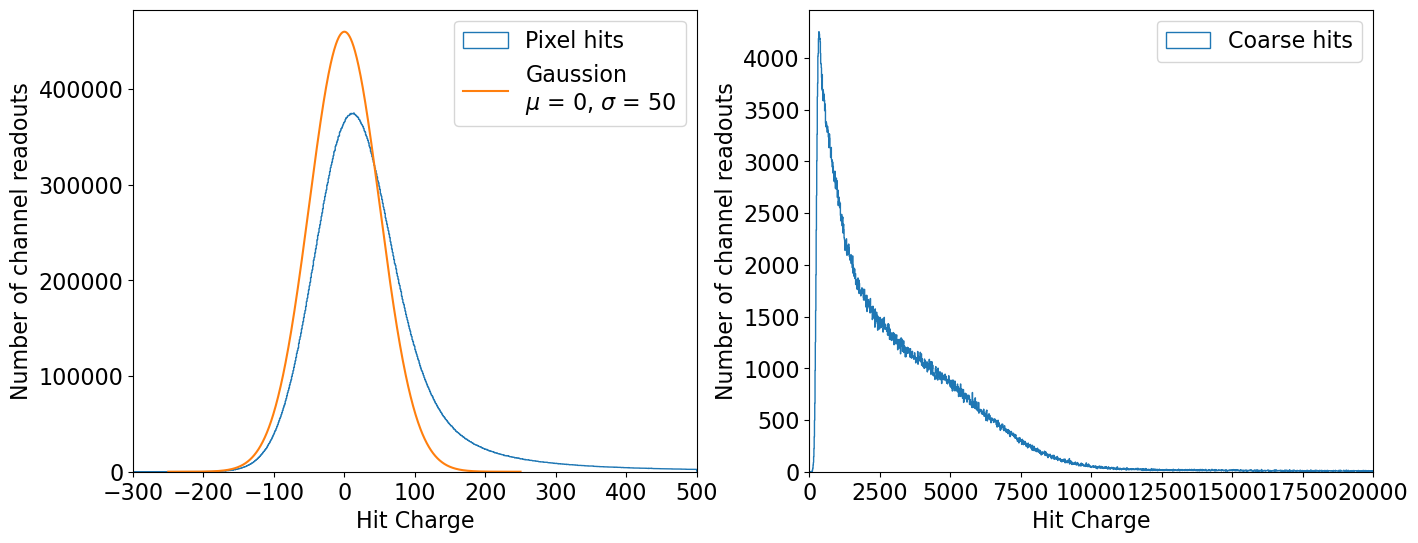

In [11]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

pBins = np.linspace(-300, 500, 801)
cBins = np.linspace(0, 20000, 2001)
fonts = 16

N = 57610780
mu = 0.0
sigma = 50

x = np.linspace(mu - 5*sigma, mu + 5*sigma, 1001)
pdf = N*(1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

ax[0].hist(dP['hit charge'], bins = pBins, histtype = 'step', label = 'Pixel hits')
ax[0].plot(x, pdf, label = f'Gaussion\n$\mu$ = 0, $\sigma$ = 50')
ax[0].set_xlim([-300, 500])
ax[1].hist(dC['hit charge'], bins = cBins, histtype = 'step', label = 'Coarse hits')
ax[1].set_xlim([0, 20000])

for i in range(2):
    ax[i].set_xlabel('Hit Charge', fontsize = fonts)
    ax[i].set_ylabel('Number of channel readouts', fontsize = fonts)
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].legend(fontsize = fonts)



In [12]:
# number of tiles with hit charge < 50, 150, 250
(dC['hit charge']<50.).sum(), (dC['hit charge']<150.).sum(), (dC['hit charge']<250.).sum()

(np.int64(0), np.int64(230), np.int64(10133))

For each charge in the coarse tile, find the corresponding charge in the pixels (by the x-y location and time),
sum over the charge in the corresponding pixels:

In [13]:
# --- Prep (keep only needed cols to reduce memory) ---
dP2 = dP.reset_index(drop = True).copy()
dC2 = dC.reset_index(drop = True).copy()

dP2["pixel_id"] = dP2.index
dC2["tile_id"]  = dC2.index

# If you have event id, keep it; otherwise remove those lines below
need_cols_p = ["pixel_id", "event id", "hit t", "pixel x", "pixel y", "hit charge"]
need_cols_c = ["tile_id",  "event id", "hit t", "tile x",  "tile y", "hit charge"]
dP2 = dP2[need_cols_p]
dC2 = dC2[need_cols_c]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
dP2 = dP2.sort_values(["event id", "hit t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []

for ev, c_ev in dC2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["hit t"].to_numpy()
    # For each tile, get [t, t+10]
    tC = c_ev["hit t"].to_numpy()

    left  = np.searchsorted(tP, tC, side = "left")
    right = np.searchsorted(tP, tC + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, hit_t, tx, ty), l, r in zip(
        c_ev[["tile_id", "hit t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "hit t", "pixel x", "pixel y", "hit charge"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["hit charge"].sum())))

# Build outputs
matches = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]
)

charge_sum = pd.DataFrame(sum_parts, columns=["tile_id", "hit_charge_sum"]).groupby("tile_id", as_index = False)["hit_charge_sum"].sum()

# Add the sum onto every matching row (and/or onto dC)
matches = matches.merge(charge_sum, on = "tile_id", how = "left")
dC2 = dC2.merge(charge_sum, on = "tile_id", how = "left")
dC2["hit_charge_sum"] = dC2["hit_charge_sum"].fillna(0)

# If you want to write back:
dC["hit_charge_sum"] = dC2.sort_values("tile_id")["hit_charge_sum"].to_numpy()

In [14]:
dC

,event id,tile tpc,tile x,tile y,hit z,hit t,hit charge,attribution,label,hit_charge_sum
0,0,0,-215.0,-165.0,86.274078,538.831055,4731.630371,"[0.9176100492477417, 0.08238980174064636, 0.0,...","[1046, 1045, -9999, -9999, -9999, -9999, -9999...",3194.735840
1,0,0,-205.0,-155.0,86.514244,540.331055,2315.703613,"[0.9040015339851379, 0.07936723530292511, 0.01...","[1049, 1047, 1048, -9999, -9999, -9999, -9999,...",1727.861572
2,0,0,-205.0,-145.0,86.033905,537.331055,3677.313721,"[0.807343065738678, 0.19265709817409515, 0.0, ...","[1051, 1050, -9999, -9999, -9999, -9999, -9999...",3218.632812
3,0,0,-205.0,-5.0,525.545227,3282.331055,1057.415894,"[0.8500276803970337, 0.09808349609375, 0.05188...","[3824, 3823, 3825, 3828, 3827, 3826, -9999, -9...",1161.645874
4,0,0,-195.0,-145.0,86.194023,538.331055,2770.572754,"[0.695894181728363, 0.30410587787628174, 0.0, ...","[1052, 1051, -9999, -9999, -9999, -9999, -9999...",2413.861328
...,...,...,...,...,...,...,...,...,...,...
1030805,999,0,175.0,165.0,354.101013,2211.563721,819.615906,"[0.902991771697998, 0.09700825810432434, 0.0, ...","[7804567, 7804566, 7808891, 7808890, 7804570, ...",0.000000
1030806,999,0,175.0,165.0,379.559052,2370.563721,1964.132935,"[0.9999998807907104, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804574, 7808891, 7808890, 7804570, 7804569, ...",1532.712036
1030807,999,0,175.0,165.0,550.480103,3438.063721,1896.229004,"[0.7888050079345703, 0.21119728684425354, 0.0,...","[7808890, 7808891, 7804574, 7804570, 7804569, ...",1816.545898
1030808,999,0,185.0,-85.0,-197.009354,-1230.436279,1229.706299,"[0.8932685852050781, 0.06489381939172745, 0.04...","[7804985, 7804983, 7804984, 7804986, -9999, -9...",1232.944214


In [61]:
dC2['ratio'] = dC2['hit_charge_sum']/dC2['hit charge']

In [62]:
dC2['ratio'].min(), dC2['ratio'].max(), dC2['hit_charge_sum'].min(), dC2['hit_charge_sum'].max()

(-2.5578510140569417, 37.03093677903935, -757.9810791015625, 80480.9453125)

Charge on pixels/charge on tile per tile

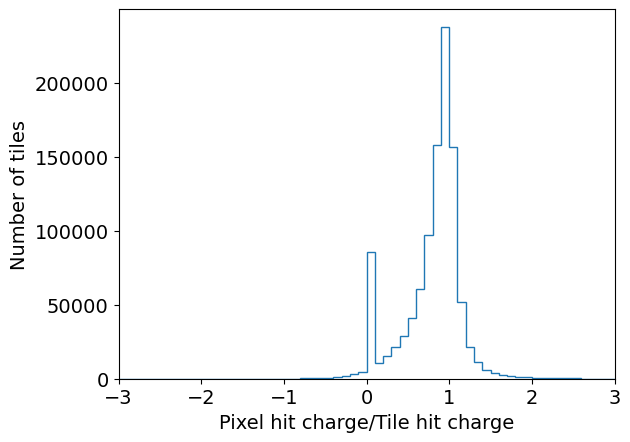

In [63]:
fig, ax = plt.subplots()

rBins = np.linspace(-3, 3, 61)
fonts = 14

ax.hist(dC2['ratio'], bins = rBins, histtype = 'step')
ax.set_xlabel('Pixel hit charge/Tile hit charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-3, 3])

ax.tick_params(axis = "both", labelsize = fonts)

1. why are there tiles with the ratio > 1?  It is consistent with Boxun's study with his clustering algorithm.  Now looking into more details...
2. why is there a peak at ratio = 0?

In [18]:
len(dC)

1030810

Fraction of the tiles with the pixel charge/tile charge > 1

In [19]:
(dC['ratio'] > 1).sum()

np.int64(261175)

In [ ]:
261175/1030810

0.253368710043558

Fraction of the tiles with the pixel charge = 0

In [ ]:
(dC['ratio'] == 0).sum()

np.int64(78381)

In [46]:
78381/1030810

0.0760382611732521

In [22]:
dC[dC.ratio>1]

,event id,tile tpc,tile x,tile y,hit z,hit t,hit charge,attribution,label,hit_charge_sum,ratio
3,0,0,-205.0,-5.0,525.545227,3282.331055,1057.415894,"[0.8500276803970337, 0.09808349609375, 0.05188...","[3824, 3823, 3825, 3828, 3827, 3826, -9999, -9...",1161.645874,1.098570
5,0,0,-195.0,-5.0,536.993347,3353.831055,532.182251,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999...",683.003357,1.283401
6,0,0,-175.0,25.0,677.172607,4229.331055,29306.937500,"[0.36649107933044434, 0.3267216682434082, 0.30...","[1980, 1981, 1982, 1979, -9999, -9999, -9999, ...",29309.484375,1.000087
11,0,0,-155.0,-115.0,-567.869263,-3546.668945,1072.740112,"[0.9027796983718872, 0.09722010791301727, 0.0,...","[1906, 1905, 178, -9999, -9999, -9999, -9999, ...",1250.374512,1.165589
15,0,0,-155.0,-55.0,555.166199,3467.331055,1175.079590,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999...",1691.526367,1.439499
...,...,...,...,...,...,...,...,...,...,...,...
1030786,999,0,145.0,65.0,381.720520,2384.063477,1183.875732,"[1.0000001192092896, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804563, 7804562, 7803332, 7803331, 7803330, ...",1445.994995,1.221408
1030790,999,0,145.0,85.0,-164.666443,-1028.436279,4322.064453,"[1.0000001192092896, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7803231, 7803453, -9999, -9999, -9999, -9999,...",4358.641602,1.008463
1030791,999,0,145.0,95.0,-214.221542,-1337.936279,6280.723145,"[1.0000001192092896, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7803071, 7803292, -9999, -9999, -9999, -9999,...",6917.283691,1.101351
1030793,999,0,145.0,115.0,160.283722,1001.063721,3931.656982,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7803787, 7803908, -9999, -9999, -9999, -9999,...",5074.476562,1.290671


Look at the segment causing one example where the ratio > 1

In [ ]:
s_0_3828 = dS[(dS.event_id==0)&(dS.segment_id==3828)]
s_0_3828

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,long_diff,pixel_plane,t_end,dEdx,dE,t,y,x,z,n_photons
3828,0,0,1525,3828,845.995483,6,3707,0.0,845.995972,309.686035,...,0.0,0,0.0,37.32098,0.057878,0.0,-7.026145,309.686584,845.995728,0.0


the waveform on a single pixel

In [ ]:
wf_0_3828 = dP[(dP['event id']==0)&(dP['label'].str[0]==3828)]['hit charge'].to_numpy()
wf_0_3828

array([  3.6506987, 323.6775   , 118.48155  , -48.32495  ,   2.7039757,
        11.12008  ,   9.09755  ,  62.392323 ,  36.819168 ,  41.78147  ,
        -3.1111982,  11.695353 ,  42.88041  ,  95.048584 ,  20.924215 ,
       -41.134544 ,  68.63068  ,  42.792446 , -46.31881  , -69.803116 ],
      dtype=float32)

All the pixels/samples with the same segment

In [ ]:
dP[(dP['event id']==0)&(dP['label'].str[0]==3828)]

,event id,pixel tpc,pixel x,pixel y,hit z,hit t,hit charge,attribution,label
420,0,0,-199.75,-7.25,536.993347,3353.831055,3.650699,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
421,0,0,-199.75,-7.25,537.073364,3354.331055,323.677490,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
422,0,0,-199.75,-7.25,537.153442,3354.831055,118.481552,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
423,0,0,-199.75,-7.25,537.233521,3355.331055,-48.324951,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
424,0,0,-199.75,-7.25,537.313538,3355.831055,2.703976,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
425,0,0,-199.75,-7.25,537.393616,3356.331055,11.120080,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
426,0,0,-199.75,-7.25,537.473694,3356.831055,9.097550,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
427,0,0,-199.75,-7.25,537.553711,3357.331055,62.392323,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
428,0,0,-199.75,-7.25,537.633789,3357.831055,36.819168,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."
429,0,0,-199.75,-7.25,537.713806,3358.331055,41.781471,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3828, -9999, -9999, -9999, -9999, -9999, -999..."


Ended up that the segment is landing in a single pixel \
Sum over the samples with the segment energy deposition, vs the samples without

In [ ]:
wf_0_3828[:3].sum(), wf_0_3828[3:].sum()

(np.float32(445.80975), np.float32(237.19365))

check the other example

In [ ]:
p_0_8246 = dP[(dP['event id']==0)&(dP['label'].str[0]==8246)]
p_0_8246

,event id,pixel tpc,pixel x,pixel y,hit z,hit t,hit charge,attribution,label
780,0,0,-153.75,-54.25,555.166199,3467.331055,108.855644,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
781,0,0,-153.75,-54.25,555.246277,3467.831055,1169.040283,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
782,0,0,-153.75,-54.25,555.326294,3468.331055,44.760437,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
783,0,0,-153.75,-54.25,555.406372,3468.831055,49.336887,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
784,0,0,-153.75,-54.25,555.486450,3469.331055,-52.378887,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
785,0,0,-153.75,-54.25,555.566467,3469.831055,-25.997269,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
786,0,0,-153.75,-54.25,555.646545,3470.331055,57.072090,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
787,0,0,-153.75,-54.25,555.726562,3470.831055,63.246353,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
788,0,0,-153.75,-54.25,555.806641,3471.331055,-3.568060,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."
789,0,0,-153.75,-54.25,555.886719,3471.831055,44.595100,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8246, -9999, -9999, -9999, -9999, -9999, -999..."


waveform of this pixel

In [ ]:
wf_0_8246 = p_0_8246['hit charge'].to_numpy()
wf_0_8246

array([ 108.855644, 1169.0403  ,   44.760437,   49.336887,  -52.378887,
        -25.997269,   57.07209 ,   63.246353,   -3.56806 ,   44.5951  ,
         34.183712,   70.06636 ,   44.96056 ,  -27.140268,  -63.408573,
        -24.055218,   49.468056,   63.582336,   20.306887,   68.599815],
      dtype=float32)

Sum over the samples with the segment energy deposition, vs the samples without

In [ ]:
wf_0_8246[:3].sum(), wf_0_8246[3:-1].sum()

(np.float32(1322.6562), np.float32(300.27005))

Find the pixel samples without any energy deposition; pure noise

In [ ]:
noise_pixel_hit = dP[dP['attribution'].str[0]==0]
noise_pixel_hit

,event id,pixel tpc,pixel x,pixel y,hit z,hit t,hit charge,attribution,label
0,0,0,-215.25,-166.75,86.274078,538.831055,17.394669,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
1,0,0,-215.25,-166.75,86.354134,539.331055,35.754356,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
3,0,0,-215.25,-166.75,86.514244,540.331055,-54.810165,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
16,0,0,-215.25,-166.75,87.554985,546.831055,-113.282669,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
17,0,0,-215.25,-166.75,87.635040,547.331055,-58.992565,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1046, 1045, -9999, -9999, -9999, -9999, -9999..."
...,...,...,...,...,...,...,...,...,...
57610775,999,0,186.75,-88.25,-194.047256,-1211.936279,26.247719,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610776,999,0,186.75,-88.25,-193.967194,-1211.436279,39.944767,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610777,999,0,186.75,-88.25,-193.887131,-1210.936279,84.618416,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."
57610778,999,0,186.75,-88.25,-193.807083,-1210.436279,32.871063,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7804986, -9999, -9999, -9999, -9999, -9999, -..."


check if the charge in these samples follows the Gaussian (the expected noise distribution)

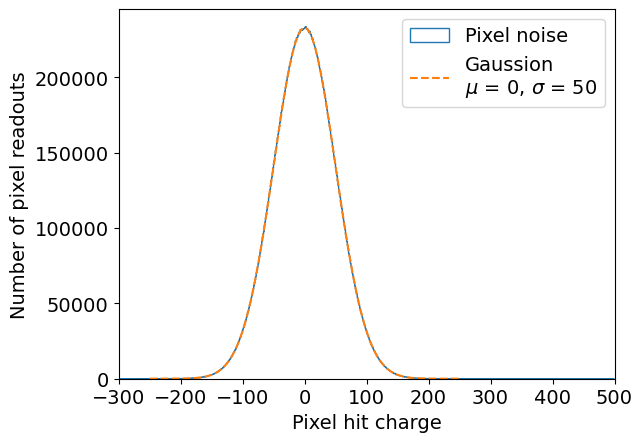

In [ ]:
fig, ax = plt.subplots()

pBins = np.linspace(-300, 500, 801)
fonts = 14

mu = 0.0
sigma = 50
N = 29191347

x = np.linspace(mu - 5*sigma, mu + 5*sigma, 1001)
pdf = N*(1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

ax.hist(noise_pixel_hit['hit charge'], bins = pBins, histtype = 'step', label = 'Pixel noise')
ax.plot(x ,pdf, linestyle = '--', label = f'Gaussion\n$\mu$ = 0, $\sigma$ = 50')
ax.set_xlabel('Pixel hit charge', fontsize = fonts)
ax.set_ylabel('Number of pixel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([-300, 500])
ax.legend(fontsize = fonts)

the sum of the charge from the noise samples

In [ ]:
noise_pixel_hit['hit charge'].sum()/29191347

np.float32(-0.010721308)

plot the waveform

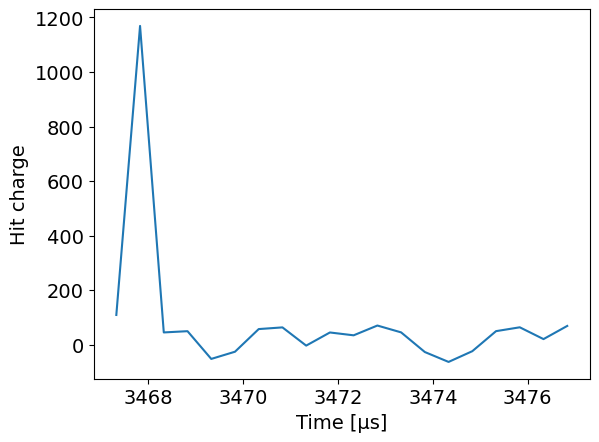

In [ ]:
fig, ax = plt.subplots()

fonts = 14

ax.plot(p_0_8246['hit t'], p_0_8246['hit charge'])

ax.set_xlabel('Time [µs]', fontsize = fonts)
ax.set_ylabel('Hit charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)

TODO:

- Try to count only the coarse and pixel hits with the hit charge > 3&sigma; or 5&sigma;, make a ratio plot
- ~~Check the energy of the G4 tracks producing only one segment~~, consider to drop them
- 3-mm pixels (asked)

In [34]:
dSperTrack = (
    dS.groupby("file_traj_id", as_index = False)
      .agg(
          pdg_id = ("pdg_id", "first"),
          segment_id = ("segment_id", "first"),   # <-- add this
          nSegments = ("file_traj_id", "size"),
          dE = ("dE", "sum"),
      )
)
dSperTrack

,file_traj_id,pdg_id,segment_id,nSegments,dE
0,0,11,0,1,0.102955
1,1,11,1,1,0.272483
2,2,11,2,1,0.091932
3,3,11,3,1,0.010307
4,4,11,4,1,0.354154
...,...,...,...,...,...
7540648,7544614,11,7810664,1,0.010890
7540649,7544615,11,7810663,1,0.014933
7540650,7544616,11,7810662,1,0.024414
7540651,7544617,11,7810661,1,0.013557


In [35]:
(dSperTrack.nSegments==1).sum()

np.int64(7363240)

In [36]:
7363240/7540653

0.9764724620003069

97.6\% of G4 tracks have only one segment

Find the segment ids for the G4 tracks depositing only one segment

In [ ]:
seg_ids_n1 = dSperTrack.loc[dSperTrack["nSegments"].eq(1), "segment_id"]
seg_ids_n1

0                0
1                1
2                2
3                3
4                4
            ...   
7540648    7810664
7540649    7810663
7540650    7810662
7540651    7810661
7540652    7810660
Name: segment_id, Length: 7363240, dtype: uint32

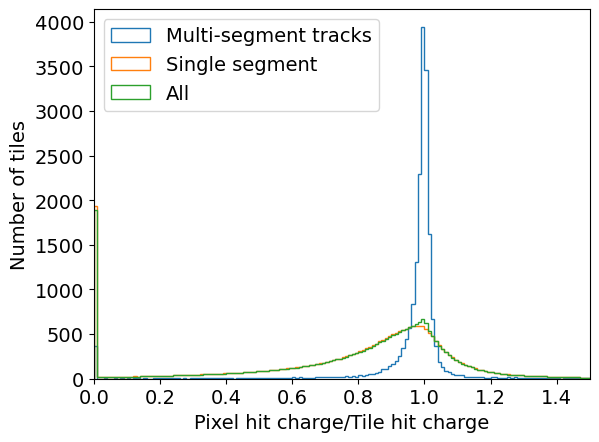

In [45]:
fig, ax = plt.subplots()

rBins = np.linspace(0, 1.5, 151)
fonts = 14

mask = dC['label'].str[0].isin(seg_ids_n1)
n = dC.loc[mask, "ratio"].shape[0]
weight1 = 2.4/97.6
weight1_arr = np.full((n,), weight1)

weightall = 2.4/100
n = dC.shape[0]
weightall_arr = np.full((n,), weightall)

ax.hist(dC.loc[~mask, 'ratio'], bins = rBins, histtype = 'step', label = 'Multi-segment tracks')
ax.hist(dC.loc[mask, 'ratio'], bins = rBins, weights = weight1_arr, histtype = 'step', label = 'Single segment')
ax.hist(dC['ratio'], bins = rBins, weights = weightall_arr, histtype = 'step', label = 'All')
ax.set_xlabel('Pixel hit charge/Tile hit charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 1.5])

ax.tick_params(axis = "both", labelsize = fonts)
ax.legend( fontsize = fonts)

In [47]:
dP2

,pixel_id,event id,hit t,pixel x,pixel y,hit charge
0,3920,0,-4032.168945,-134.25,63.25,3138.475586
1,3921,0,-4031.668945,-134.25,63.25,-36.469757
2,3922,0,-4031.168945,-134.25,63.25,0.441278
3,3923,0,-4030.668945,-134.25,63.25,110.414970
4,3924,0,-4030.168945,-134.25,63.25,-84.465332
...,...,...,...,...,...,...
57610775,57560318,999,7984.563477,-113.75,121.25,-37.719944
57610776,57560259,999,7985.063477,-114.25,120.75,-13.722581
57610777,57560279,999,7985.063477,-114.25,121.25,-28.646446
57610778,57560299,999,7985.063477,-113.75,120.75,-18.339041


Only sum over the pixel hit charge > 3&sigma; (=150)

In [48]:
# --- Prep (keep only needed cols to reduce memory) ---
# dP2 = dP.reset_index(drop = True).copy()
# dC2 = dC.reset_index(drop = True).copy()

# dP2["pixel_id"] = dP2.index
# dC2["tile_id"]  = dC2.index

# If you have event id, keep it; otherwise remove those lines below
# need_cols_p = ["pixel_id", "event id", "hit t", "pixel x", "pixel y", "hit charge"]
# need_cols_c = ["tile_id",  "event id", "hit t", "tile x",  "tile y", "hit charge"]
# dP2 = dP2[need_cols_p]
# dC2 = dC2[need_cols_c]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
# dP2 = dP2.sort_values(["event id", "hit t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []
threshold = 3*50

for ev, c_ev in dC2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["hit t"].to_numpy()
    # For each tile, get [t, t+10]
    tC = c_ev["hit t"].to_numpy()

    left  = np.searchsorted(tP, tC, side = "left")
    right = np.searchsorted(tP, tC + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, hit_t, tx, ty), l, r in zip(
        c_ev[["tile_id", "hit t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5) &
            (sub["hit charge"] > threshold)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "hit t", "pixel x", "pixel y", "hit charge"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["hit charge"].sum())))

# Build outputs
matches_3sd = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]
)

charge_sum_3sd = pd.DataFrame(sum_parts, columns=["tile_id", "hit_charge_sum_3sd"]).groupby("tile_id", as_index = False)["hit_charge_sum_3sd"].sum()

# Add the sum onto every matching row (and/or onto dC)
matches_3sd = matches_3sd.merge(charge_sum_3sd, on = "tile_id", how = "left")
dC2 = dC2.merge(charge_sum_3sd, on = "tile_id", how = "left")
dC2["hit_charge_sum_3sd"] = dC2["hit_charge_sum_3sd"].fillna(0)

# If you want to write back:
dC["hit_charge_sum_3sd"] = dC2.sort_values("tile_id")["hit_charge_sum_3sd"].to_numpy()

In [64]:
dC2['ratio_3sd'] = dC2['hit_charge_sum_3sd']/dC2['hit charge']

In [65]:
dC2['ratio_3sd'].min(), dC2['ratio_3sd'].max(), dC2['hit_charge_sum_3sd'].min(), dC2['hit_charge_sum_3sd'].max()

(0.0, 36.09804207293909, 0.0, 76702.328125)

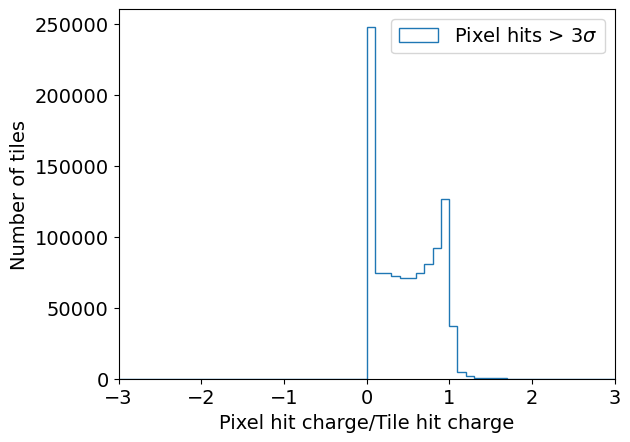

In [66]:
fig, ax = plt.subplots()

rBins = np.linspace(-3, 3, 61)
fonts = 14

ax.hist(dC2['ratio_3sd'], bins = rBins, histtype = 'step', label = r'Pixel hits > 3$\sigma$')
ax.set_xlabel('Pixel hit charge/Tile hit charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-3, 3])

ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [67]:
(dC2['ratio_3sd'] > 1).sum()

np.int64(46269)

In [68]:
dC2.shape[0]

1030810

In [54]:
46269/1030810

0.04488606047671249

In [69]:
(dC2['ratio_3sd'] == 0).sum()

np.int64(222568)

Only sum over the pixel hit charge > 5&sigma; (=250)

In [56]:
# --- Prep (keep only needed cols to reduce memory) ---
# dP2 = dP.reset_index(drop = True).copy()
# dC2 = dC.reset_index(drop = True).copy()

# dP2["pixel_id"] = dP2.index
# dC2["tile_id"]  = dC2.index

# If you have event id, keep it; otherwise remove those lines below
# need_cols_p = ["pixel_id", "event id", "hit t", "pixel x", "pixel y", "hit charge"]
# need_cols_c = ["tile_id",  "event id", "hit t", "tile x",  "tile y", "hit charge"]
# dP2 = dP2[need_cols_p]
# dC2 = dC2[need_cols_c]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
# dP2 = dP2.sort_values(["event id", "hit t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []
threshold = 5*50

for ev, c_ev in dC2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["hit t"].to_numpy()
    # For each tile, get [t, t+10]
    tC = c_ev["hit t"].to_numpy()

    left  = np.searchsorted(tP, tC, side = "left")
    right = np.searchsorted(tP, tC + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, hit_t, tx, ty), l, r in zip(
        c_ev[["tile_id", "hit t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5) &
            (sub["hit charge"] > threshold)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "hit t", "pixel x", "pixel y", "hit charge"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["hit charge"].sum())))

# Build outputs
matches_5sd = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "hit t", "pixel x", "pixel y"]
)

charge_sum_5sd = pd.DataFrame(sum_parts, columns=["tile_id", "hit_charge_sum_5sd"]).groupby("tile_id", as_index = False)["hit_charge_sum_5sd"].sum()

# Add the sum onto every matching row (and/or onto dC)
matches_5sd = matches_5sd.merge(charge_sum_5sd, on = "tile_id", how = "left")
dC2 = dC2.merge(charge_sum_5sd, on = "tile_id", how = "left")
dC2["hit_charge_sum_5sd"] = dC2["hit_charge_sum_5sd"].fillna(0)

# If you want to write back:
dC["hit_charge_sum_5sd"] = dC2.sort_values("tile_id")["hit_charge_sum_5sd"].to_numpy()

In [57]:
dC['ratio_5sd'] = dC['hit_charge_sum_5sd']/dC['hit charge']

In [58]:
dC['ratio_5sd'].min(), dC['ratio_5sd'].max(), dC['hit_charge_sum_5sd'].min(), dC['hit_charge_sum_5sd'].max()

(0.0, 35.17289604580493, 0.0, 72500.2734375)

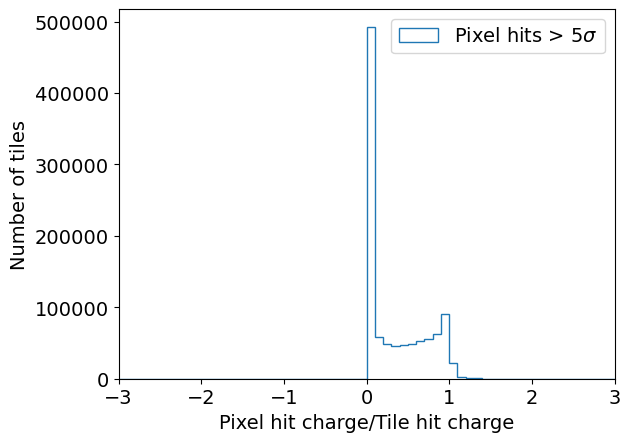

In [59]:
fig, ax = plt.subplots()

rBins = np.linspace(-3, 3, 61)
fonts = 14

ax.hist(dC['ratio_5sd'], bins = rBins, histtype = 'step', label = r'Pixel hits > 5$\sigma$')
ax.set_xlabel('Pixel hit charge/Tile hit charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-3, 3])

ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [60]:
(dC['ratio_5sd'] > 1).sum()

np.int64(27332)

Question: how is the ionization simulated in GAMPixPy?  Is it voxelizing along a segment?  What is the traverse/longitudinal diffusion scale?

edep-sim segments (might be too large) v.s. Dan's/my G4 wrapper's segment (dx)